In [23]:
import numpy as np
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from utils.load import load_all_images, extract_load_features, log_confusion_matrix
from layers.Conv import Conv
from layers.NN import NeuralNetwork
from utils.logger import Logger
from utils.model_saver import save_complete_training, ModelSaver
import matplotlib.pyplot as plt

In [24]:
logger = Logger(log_dir='logs')

IMAGE_SIZE = (128, 128)
POOL_SIZE = 2
HIDDEN_LAYERS = [256, 128]
LEARNING_RATE = 0.01
EPOCHS = 600
DATA_ROOT = 'data/raw'

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

CLASS_TO_INDEX

INFO - Logger initialized. Log file: logs/training_log_20260406_212456.log


{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [25]:
logger.log_hyperparameters({
        'image_size': IMAGE_SIZE,
        'pool_size': POOL_SIZE,
        'hidden_layers': HIDDEN_LAYERS,
        'learning_rate': LEARNING_RATE,
        'epochs': EPOCHS,
})

INFO - ==================================================
INFO - HYPERPARAMETERS
INFO - ==================================================
INFO - image_size: (128, 128)
INFO - pool_size: 2
INFO - hidden_layers: [256, 128]
INFO - learning_rate: 0.01
INFO - epochs: 600
INFO - ==================================================


In [26]:
logger.info("[1/4] Memuat dataset...")
images_per_class = load_all_images(
   data_root=DATA_ROOT,
   class_names=CLASS_NAMES,
   image_size=IMAGE_SIZE,
)


INFO - [1/4] Memuat dataset...


  Loaded   400 gambar dari folder 'glioma'
  Loaded   400 gambar dari folder 'meningioma'
  Loaded   400 gambar dari folder 'notumor'
  Loaded   400 gambar dari folder 'pituitary'


In [27]:
len(images_per_class["glioma"])

400

In [28]:
all_images = []
all_labels = []
for class_name in CLASS_NAMES:
   imgs = images_per_class[class_name]
   all_images.append(imgs)
   all_labels.extend([CLASS_TO_INDEX[class_name]] * len(imgs))

In [29]:
logger.info(f"Jumlah Image {len(all_images) } dan Jumlah Label {len(all_labels)}")

INFO - Jumlah Image 4 dan Jumlah Label 1600


In [30]:
X_all = np.concatenate(all_images, axis=0)
y_all_labels = np.array(all_labels)

num_classes = len(CLASS_NAMES)
y_all = np.zeros((len(y_all_labels), num_classes))
print(y_all)

for i, label in enumerate(y_all_labels):
   y_all[i, label] = 1.0

print(y_all)

y_all_labels


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 ...
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


array([0, 0, 0, ..., 3, 3, 3], shape=(1600,))

In [31]:
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
   X_all, y_all, y_all_labels,
   test_size=0.2,
   stratify=y_all_labels,
)

logger.info(f"Total data: {X_all.shape[0]} samples")
logger.info(f"Train/Test split: {X_train.shape[0]} train, {X_test.shape[0]} test (test_size=0.2, stratified)")

logger.log_dataset_info({
        'total_samples': X_all.shape[0],
        'train_samples': X_train.shape[0],
        'test_samples': X_test.shape[0],
        'image_size': IMAGE_SIZE,
        'num_classes': len(CLASS_NAMES),
        'classes': str(CLASS_NAMES),
    })


INFO - Total data: 1600 samples
INFO - Train/Test split: 1280 train, 320 test (test_size=0.2, stratified)
INFO - ==================================================
INFO - DATASET INFORMATION
INFO - ==================================================
INFO - total_samples: 1600
INFO - train_samples: 1280
INFO - test_samples: 320
INFO - image_size: (128, 128)
INFO - num_classes: 4
INFO - classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
INFO - ==================================================


In [10]:
logger.info("[2/4] Feature extraction Convolution...")
conv = Conv(pool_size=POOL_SIZE)
conv.info(logger=logger)


t0 = time.time()
X_train_feat, X_test_feat = extract_load_features(conv, X_train, X_test, logger)
logger.info(f"Waktu feature extraction: {time.time() - t0:.1f}s")
logger.info(f"Train features: {X_train_feat.shape}")
logger.info(f"Test  features: {X_test_feat.shape}")

INFO - [2/4] Feature extraction Convolution...
INFO - Conv Layer:
INFO -   Kernel size : 3x3
INFO -   Kernel      : [[-1.0, -1.0, -1.0], [-1.0, 8.0, -1.0], [-1.0, -1.0, -1.0]]
INFO -   Pool size   : 2
INFO - Mengekstrak fitur training...
Training features: 100%|██████████| 1280/1280 [00:59<00:00, 21.65it/s]
INFO - Mengekstrak fitur testing...
Testing features: 100%|██████████| 320/320 [00:14<00:00, 22.09it/s]
INFO - Fitur disimpan ke data/extract/numpy/
INFO - Gambar hasil feature extraction disimpan ke data/extract/gambar/
INFO - Waktu feature extraction: 73.7s
INFO - Train features: (1280, 900)
INFO - Test  features: (320, 900)


In [11]:
feature_dim = conv.get_feature_dim(IMAGE_SIZE)
logger.info(f"Feature dimension: {feature_dim}")

INFO - Feature dimension: 900


In [12]:
nn = NeuralNetwork(
   input_dim=feature_dim,
   hidden_layers=HIDDEN_LAYERS,
   output_dim=num_classes,
   learning_rate=LEARNING_RATE
)

In [13]:
nn.info(logger=logger)

t1 = time.time()
history = nn.train(
   X_train_feat,
   y_train,
   epochs=EPOCHS,
   logger=logger,
)
logger.info(f"Waktu training: {time.time() - t1:.1f}s")

INFO - Neural Network Architecture:
INFO -   Layers        : [900, 256, 128, 4]
INFO -   Learning rate : 0.01
INFO -   Layer 1:   900 ->  256  (ReLU)  [230,656 params]
INFO -   Layer 2:   256 ->  128  (ReLU)  [32,896 params]
INFO -   Layer 3:   128 ->    4  (Softmax)  [516 params]
INFO -   Total parameters: 264,068
Training: 100%|██████████| 600/600 [00:12<00:00, 48.00epoch/s, loss=0.0258, acc=1.0000]
INFO - Waktu training: 12.5s


In [14]:
logger.info("[4/4] Evaluasi Model...")
test_loss, test_acc = nn.evaluate(X_test_feat, y_test, y_labels=y_test_labels)
y_pred = nn.predict(X_test_feat)

logger.log_metrics({
   'test_loss': test_loss,
   'test_accuracy': test_acc,
})

INFO - [4/4] Evaluasi Model...
INFO - ==================================================
INFO - EVALUATION METRICS
INFO - ==================================================
INFO - test_loss: 1.3133
INFO - test_accuracy: 0.6719
INFO - ==================================================


In [15]:
test_loss, test_acc

(np.float64(1.3132916482255699), np.float64(0.671875))

In [16]:
logger.info("\nClassification Report:")
logger.info(classification_report(y_test_labels, y_pred, target_names=CLASS_NAMES))

INFO - 
Classification Report:
INFO -               precision    recall  f1-score   support

      glioma       0.60      0.53      0.56        80
  meningioma       0.51      0.46      0.49        80
     notumor       0.76      0.82      0.79        80
   pituitary       0.77      0.88      0.82        80

    accuracy                           0.67       320
   macro avg       0.66      0.67      0.66       320
weighted avg       0.66      0.67      0.66       320



In [17]:
logger.info("\nConfusion Matrix:")
log_confusion_matrix(y_test_labels, y_pred, CLASS_NAMES, logger)
logger.info("✓ Project selesai!")

INFO - 
Confusion Matrix:
INFO -                     glioma  meningioma     notumor   pituitary
INFO -   ------------------------------------------------------------
INFO -         glioma          42          22           7           9
INFO -     meningioma          19          37          13          11
INFO -        notumor           6           7          66           1
INFO -      pituitary           3           6           1          70
INFO - ✓ Project selesai!


## Visualisasi Training dan Evaluasi

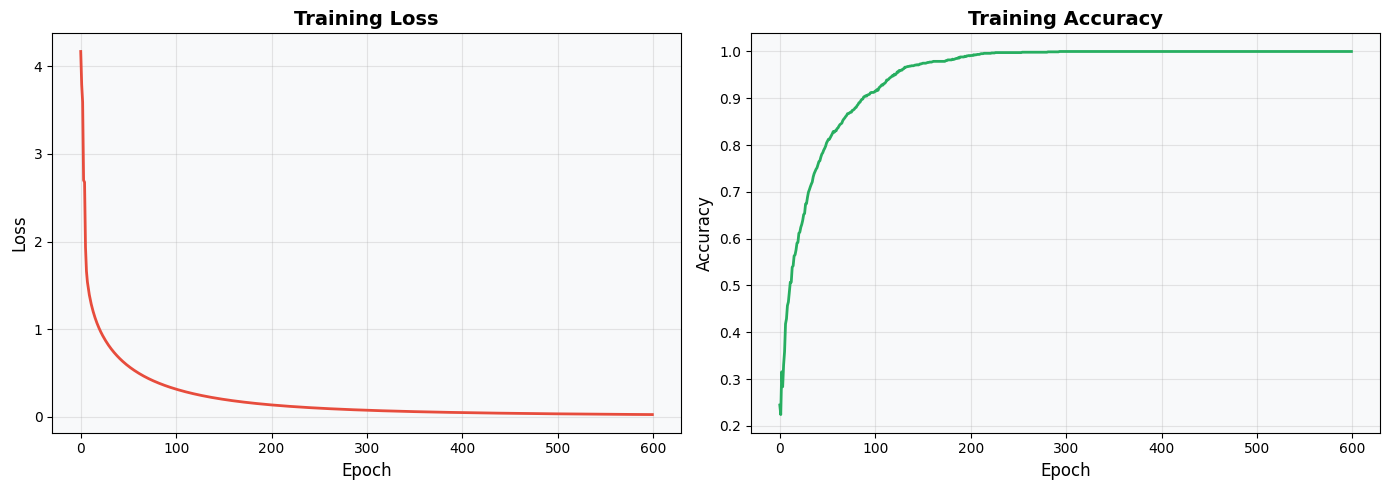

INFO - ✓ Diagram loss dan accuracy tersimpan!


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], linewidth=2, color='#e74c3c')
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

axes[1].plot(history['train_acc'], linewidth=2, color='#27ae60')
axes[1].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('logs/training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

logger.info("✓ Diagram loss dan accuracy tersimpan!")

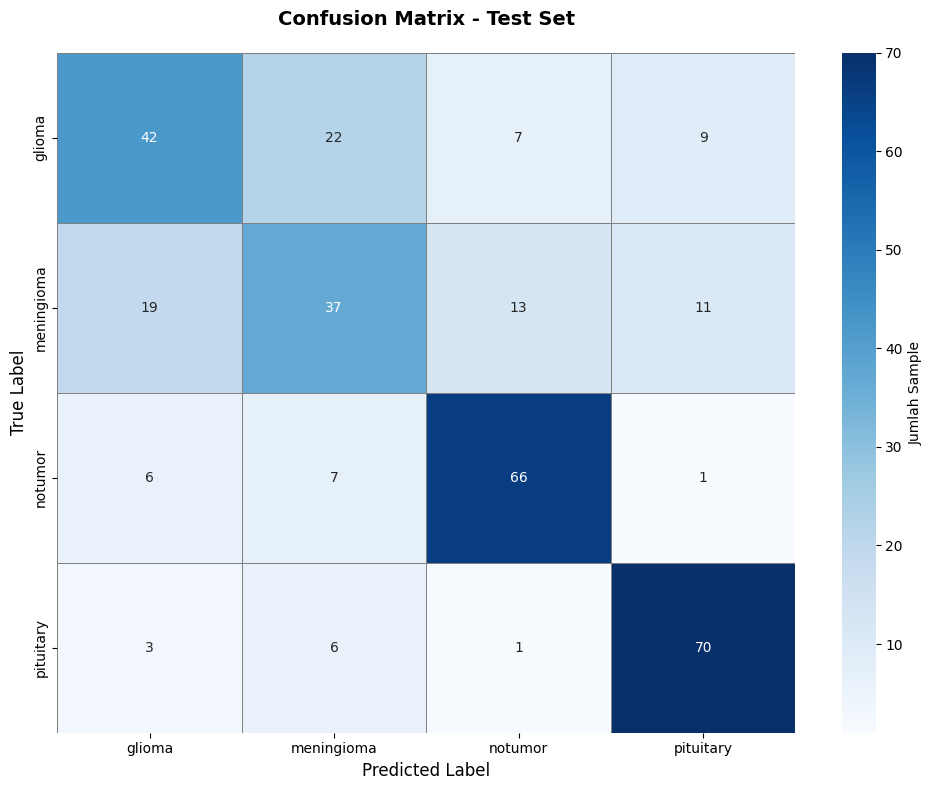

INFO - ✓ Diagram confusion matrix tersimpan!


In [ ]:
from sklearn.metrics import confusion_matrix as cm_calc
import seaborn as sns

cm = cm_calc(y_test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={'label': 'Jumlah Sample'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

logger.info("✓ Diagram confusion matrix tersimpan!")

In [ ]:
print("=" * 60)
print("RINGKASAN PERFORMA MODEL")
print("=" * 60)
print(f"\nMetrik Utama:")
print(f"   Loss Akhir:        {history['train_loss'][-1]:.4f}")
print(f"   Akurasi Akhir:     {history['train_acc'][-1]:.4f}")
print(f"\nTest Set Performance:")
print(f"   Test Loss:         {test_loss:.4f}")
print(f"   Test Accuracy:     {test_acc:.4f}")
print(f"\nFile Output:")
print(f"   ✓ logs/training_metrics.png")
print(f"   ✓ logs/confusion_matrix.png")
print("=" * 60)

RINGKASAN PERFORMA MODEL

Metrik Utama:
   Loss Akhir:        0.0258
   Akurasi Akhir:     1.0000

Test Set Performance:
   Test Loss:         1.3133
   Test Accuracy:     0.6719

File Output:
   ✓ logs/training_metrics.png
   ✓ logs/confusion_matrix.png


## Penyimpanan Model dan Hasil Training

In [21]:
# Simpan model lengkap dengan hasil training
hyperparameters = {
    'image_size': IMAGE_SIZE,
    'pool_size': POOL_SIZE,
    'hidden_layers': HIDDEN_LAYERS,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,
    'train_samples': X_train.shape[0],
    'test_samples': X_test.shape[0],
}

metrics = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_acc),
    'final_train_loss': float(history['train_loss'][-1]),
    'final_train_accuracy': float(history['train_acc'][-1]),
}

# Simpan model
saved_files = save_complete_training(
    nn=nn,
    conv=conv,
    history=history,
    metrics=metrics,
    hyperparameters=hyperparameters,
    logger=logger,
    model_dir='models'
)

logger.info("\n🎉 Training dan penyimpanan model BERHASIL!")


INFO - ============================================================
INFO - MODEL TRAINING RESULTS SAVED
INFO - ============================================================
INFO - ✓ Neural Network: models/full_model_nn_20260406_212456.pkl
INFO - ✓ Weights Npz: models/full_model_weights_20260406_212456.npz
INFO - ✓ Conv Layer: models/full_model_conv_20260406_212456.pkl
INFO - ✓ Results: models/full_model_results_20260406_212456.json
INFO - ============================================================
INFO - 
🎉 Training dan penyimpanan model BERHASIL!
